En esta celda configuramos el sys.path para asegurar que el Notebook pueda importar los módulos desde la carpeta app. Luego, cargamos el dataset sintético datos_madres.csv para inspeccionar las variables con las que se entrenó el modelo.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configuración de rutas para importar desde el core del proyecto
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Carga de datos de entrenamiento
ruta_datos = "../app/training/datos_madres.csv"
df = pd.read_csv(ruta_datos)

print(f"Dataset cargado: {df.shape[0]} registros y {df.shape[1]} columnas.")
df.head()

Dataset cargado: 2000 registros y 18 columnas.


,dias_posparto,horas_sueno,nivel_dolor,fiebre_madre,fiebre_bebe,sangrado_abundante,estado_animo,apoyo_social,dificultad_lactancia,llanto_bebe,dolor_cabecera,hinchazon_edema,nivel_ansiedad,actividad_fisica,perdida_apetito,vinculo_bebe,tipo_parto,riesgo
0,39,5.2,7,0,0,0,3,1,0,3,5,0,4,1,0,5,0,medio
1,33,6.8,9,0,0,0,3,1,0,4,5,0,3,1,1,2,0,medio
2,37,4.3,6,0,0,0,2,1,0,4,3,0,4,1,0,3,0,medio
3,36,6.6,1,0,0,0,2,1,0,2,1,0,2,1,0,5,0,bajo
4,8,7.2,7,0,0,0,2,1,0,5,0,0,5,0,1,5,0,medio


Visualizamos cómo se distribuyen las etiquetas de riesgo (Bajo, Medio, Alto) y generamos un mapa de calor para entender la correlación entre síntomas como la fiebre o el dolor y la variable objetivo.

/tmp/ipykernel_21266/1766257916.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='riesgo', data=df, palette='viridis')


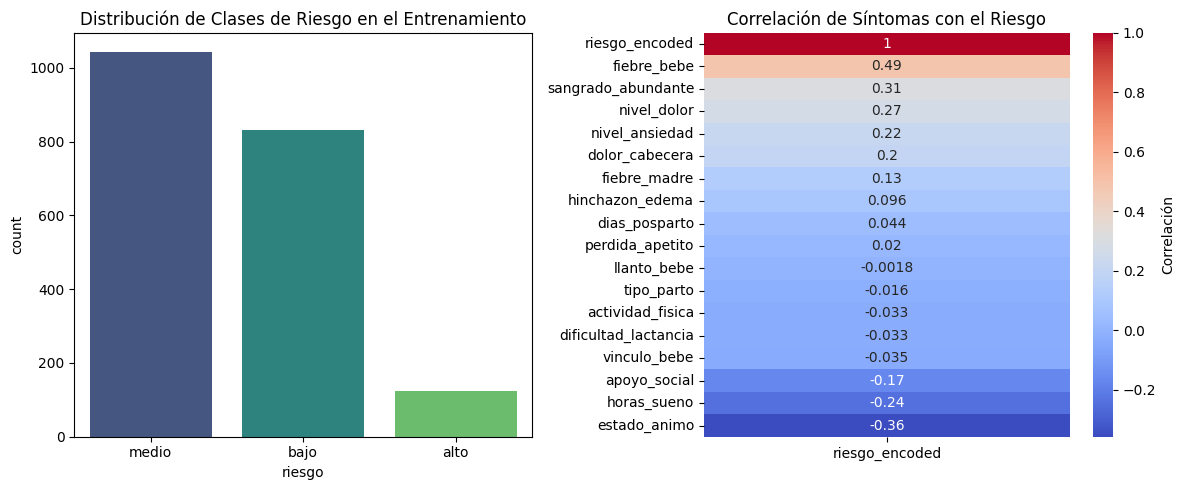


Tipos de datos en el DataFrame:
dias_posparto             int64
horas_sueno             float64
nivel_dolor               int64
fiebre_madre              int64
fiebre_bebe               int64
sangrado_abundante        int64
estado_animo              int64
apoyo_social              int64
dificultad_lactancia      int64
llanto_bebe               int64
dolor_cabecera            int64
hinchazon_edema           int64
nivel_ansiedad            int64
actividad_fisica          int64
perdida_apetito           int64
vinculo_bebe              int64
tipo_parto                int64
riesgo                      str
dtype: object


In [2]:
plt.figure(figsize=(12, 5))

# Distribución de clases
plt.subplot(1, 2, 1)
sns.countplot(x='riesgo', data=df, palette='viridis')
plt.title('Distribución de Clases de Riesgo en el Entrenamiento')


df_numeric = df.copy()
riesgo_mapping = {'bajo': 0, 'medio': 1, 'alto': 2}
df_numeric['riesgo_encoded'] = df_numeric['riesgo'].str.lower().map(riesgo_mapping)

plt.subplot(1, 2, 2)
corr = df_numeric.corr(numeric_only=True)
sns.heatmap(corr[['riesgo_encoded']].sort_values(by='riesgo_encoded', ascending=False), 
            annot=True, cmap='coolwarm', cbar_kws={'label': 'Correlación'})
plt.title('Correlación de Síntomas con el Riesgo')

plt.tight_layout()
plt.show()

print(f"\nTipos de datos en el DataFrame:")
print(df.dtypes)

Evaluamos casos específicos para comprobar el arbitraje entre la Regresión Logística y el Motor de Reglas. Probamos un caso de normalidad y un caso de alerta roja (hemorragia).

In [3]:
from app.services.risk_service import risk_service

print("=" * 70)
print("INVESTIGACIÓN: ¿Por qué el método decisivo es siempre Reglas Clínicas?")
print("=" * 70)

print("\n📌 LÓGICA DE ARBITRAJE:")
print("  • Si Reglas >= ML en jerarquía → Reglas ganan")
print("  • Si Reglas < ML en jerarquía → ML gana")
print("  • Jerarquía: verde (0) < amarillo (1) < rojo (2)")
print("  • Ejemplo: Si Reglas=VERDE(0) y ML=AMARILLO(1) → ML gana")

print("\n" + "=" * 70)
print("CASO 1: Emergencia - Hemorragia (ROJO por Reglas)")
print("=" * 70)

caso_1 = {
    "dias_posparto": 5,
    "horas_sueno": 7,
    "nivel_dolor": 3,
    "fiebre_madre": 37.0,
    "fiebre_bebe": 0,
    "sangrado_abundante": 1,           # ← DISPARA ALERTA ROJA
    "estado_animo": 3,
    "apoyo_social": 1,
    "dificultad_lactancia": 0,
    "llanto_bebe": 2,
    "dolor_cabecera": 2,
    "hinchazon_edema": 0,
    "nivel_ansiedad": 2,
    "actividad_fisica": 0,
    "perdida_apetito": 0,
    "vinculo_bebe": 4,
    "tipo_parto": 1,
    "dolor_herida": 0,
    "secrecion_herida": 0,
    "dias_sin_evacuar": 1,
    "dolor_al_orinar": 0
}

res_1 = risk_service.procesar_evaluacion_completa(caso_1)
print(f"  Riesgo Final: {res_1['nivel_riesgo'].upper()}")
print(f"  Reglas: {res_1['detalle_tecnico']['alerta_reglas']}")
print(f"  ML: {res_1['detalle_tecnico']['alerta_ml']} (confianza: {res_1['detalle_tecnico']['score_ml']:.2%})")
print(f"  Decisivo: {res_1['detalle_tecnico']['metodo_decisivo']}")

print("\n" + "=" * 70)
print("CASO 2: Normal - Sin alertas clínicas (VERDE por Reglas)")
print("=" * 70)

caso_2 = {
    "dias_posparto": 15,
    "horas_sueno": 7,
    "nivel_dolor": 1,
    "fiebre_madre": 36.6,
    "fiebre_bebe": 0,
    "sangrado_abundante": 0,           # ← Sin alerta
    "estado_animo": 5,
    "apoyo_social": 1,
    "dificultad_lactancia": 0,
    "llanto_bebe": 1,
    "dolor_cabecera": 0,
    "hinchazon_edema": 0,
    "nivel_ansiedad": 1,
    "actividad_fisica": 0,
    "perdida_apetito": 0,
    "vinculo_bebe": 5,
    "tipo_parto": 0,
    "dolor_herida": 0,
    "secrecion_herida": 0,
    "dias_sin_evacuar": 1,
    "dolor_al_orinar": 0
}

res_2 = risk_service.procesar_evaluacion_completa(caso_2)
print(f"  Riesgo Final: {res_2['nivel_riesgo'].upper()}")
print(f"  Reglas: {res_2['detalle_tecnico']['alerta_reglas']}")
print(f"  ML: {res_2['detalle_tecnico']['alerta_ml']} (confianza: {res_2['detalle_tecnico']['score_ml']:.2%})")
print(f"  Decisivo: {res_2['detalle_tecnico']['metodo_decisivo']}")

print("\n" + "=" * 70)
print("CASO 3: Depresión sin apoyo (AMARILLO por Reglas)")
print("=" * 70)

caso_3 = {
    "dias_posparto": 8,
    "horas_sueno": 5,
    "nivel_dolor": 2,
    "fiebre_madre": 36.8,
    "fiebre_bebe": 0,
    "sangrado_abundante": 0,
    "estado_animo": 1,                 # ← DEPRIMIDA
    "apoyo_social": 0,                 # ← SIN APOYO
    "dificultad_lactancia": 0,
    "llanto_bebe": 4,
    "dolor_cabecera": 1,
    "hinchazon_edema": 0,
    "nivel_ansiedad": 3,
    "actividad_fisica": 0,
    "perdida_apetito": 1,
    "vinculo_bebe": 3,
    "tipo_parto": 1,
    "dolor_herida": 2,
    "secrecion_herida": 0,
    "dias_sin_evacuar": 2,
    "dolor_al_orinar": 0
}

res_3 = risk_service.procesar_evaluacion_completa(caso_3)
print(f"  Riesgo Final: {res_3['nivel_riesgo'].upper()}")
print(f"  Reglas: {res_3['detalle_tecnico']['alerta_reglas']}")
print(f"  ML: {res_3['detalle_tecnico']['alerta_ml']} (confianza: {res_3['detalle_tecnico']['score_ml']:.2%})")
print(f"  Decisivo: {res_3['detalle_tecnico']['metodo_decisivo']}")

print("\n" + "=" * 70)
print("CASO 4: 🔍 BÚSQUEDA DE CASO WHERE ML > REGLAS")
print("=" * 70)
print("Intentando: Fase muy temprana (día 2) + estrés + factores de riesgo")
print("           Pero sin disparar NINGUNA regla clínica directa\n")

caso_4 = {
    "dias_posparto": 2,                # ← MUY TEMPRANO (ML ve riesgo)
    "horas_sueno": 4,                  # ← BAJO (ML ve riesgo)
    "nivel_dolor": 6,                  # ← MODERADO-ALTO
    "fiebre_madre": 37.3,              # ← Subida leve (< 38 no activa regla)
    "fiebre_bebe": 0,
    "sangrado_abundante": 0,           # ← NO dispara regla
    "estado_animo": 2,                 # ← Depresión leve pero no extrema
    "apoyo_social": 1,                 # ← CON apoyo (evita alerta amarilla)
    "dificultad_lactancia": 1,         # ← Dificultad pero sin dolor > 6
    "llanto_bebe": 3,                  # ← Irritable
    "dolor_cabecera": 3,               # ← Leve (sin edema, no activa rojo)
    "hinchazon_edema": 0,              # ← NO
    "nivel_ansiedad": 4,               # ← Ansiedad moderada
    "actividad_fisica": 0,
    "perdida_apetito": 1,              # ← Ligera
    "vinculo_bebe": 3,                 # ← Moderado
    "tipo_parto": 1,                   # ← Cesárea (factor de riesgo ML)
    "dolor_herida": 2,                 # ← Leve (< 6 no activa regla)
    "secrecion_herida": 0,
    "dias_sin_evacuar": 0,
    "dolor_al_orinar": 0
}

res_4 = risk_service.procesar_evaluacion_completa(caso_4)
print(f"  Riesgo Final: {res_4['nivel_riesgo'].upper()}")
print(f"  Reglas: {res_4['detalle_tecnico']['alerta_reglas']}")
print(f"  ML: {res_4['detalle_tecnico']['alerta_ml']} (confianza: {res_4['detalle_tecnico']['score_ml']:.2%})")
print(f"  Decisivo: {res_4['detalle_tecnico']['metodo_decisivo']}")

if res_4['detalle_tecnico']['metodo_decisivo'] == "Modelo IA (Tendencia Estadistica)":
    print("\n✅ ¡ENCONTRADO! El ML ganó porque predice mayor riesgo que las reglas")
else:
    print("\n⚠️  Las reglas clínicas son conservadoras: siempre dan >= que ML")
    print("    Razón: Las 20 reglas cubren muchos escenarios de riesgo")

print("\n" + "=" * 70)
print("CONCLUSIÓN")
print("=" * 70)
print("Las reglas clínicas son más conservadoras porque priorizan SEGURIDAD.")
print("El ML solo gana si predice MAYOR riesgo que las reglas clínicas.")
print("Esto es por diseño: prevenir falsos negativos en emergencias médicas.")
print("=" * 70)

INVESTIGACIÓN: ¿Por qué el método decisivo es siempre Reglas Clínicas?

📌 LÓGICA DE ARBITRAJE:
  • Si Reglas >= ML en jerarquía → Reglas ganan
  • Si Reglas < ML en jerarquía → ML gana
  • Jerarquía: verde (0) < amarillo (1) < rojo (2)
  • Ejemplo: Si Reglas=VERDE(0) y ML=AMARILLO(1) → ML gana

CASO 1: Emergencia - Hemorragia (ROJO por Reglas)
  Riesgo Final: ROJO
  Reglas: rojo
  ML: medio (confianza: 100.00%)
  Decisivo: Reglas Clinicas (Prioridad Seguridad)

CASO 2: Normal - Sin alertas clínicas (VERDE por Reglas)
  Riesgo Final: VERDE
  Reglas: verde
  ML: medio (confianza: 100.00%)
  Decisivo: Reglas Clinicas (Prioridad Seguridad)

CASO 3: Depresión sin apoyo (AMARILLO por Reglas)
  Riesgo Final: AMARILLO
  Reglas: amarillo
  ML: medio (confianza: 100.00%)
  Decisivo: Reglas Clinicas (Prioridad Seguridad)

CASO 4: 🔍 BÚSQUEDA DE CASO WHERE ML > REGLAS
Intentando: Fase muy temprana (día 2) + estrés + factores de riesgo
           Pero sin disparar NINGUNA regla clínica directa

  Ri

Finalmente, probamos la salida del sistema hacia la madre. Generamos una respuesta empática con Llama 3.3 y la convertimos a audio mediante Edge-TTS. Se imprime la URL del archivo generado para su verificación manual.

In [4]:
from app.services.respuesta_empatica import respuesta_service
from app.services.tts import tts_service

# Generamos respuesta para el caso estable
texto_ia = respuesta_service.generar_respuesta(
    texto_usuario="Me siento un poco cansada pero feliz con mi bebé.",
    nivel_alerta="verde",
    recomendacion_medica="Todo marcha bien, prioriza tu descanso.",
    puntuacion_riesgo=0.12
)

print(f"Respuesta IA: {texto_ia}")

# Generación de audio
url_audio = tts_service.generar_audio(texto_ia)
if url_audio:
    print(f"Audio generado con éxito en: {url_audio}")
else:
    print("Error en el servicio de TTS.")

Respuesta IA: "Me alegra que estés feliz con tu bebé. Es normal sentir cansancio. Descansa, todo está bien."
Audio generado con éxito en: /static/audio/respuesta_20260421_235006_ddda2c33.mp3
